# 03 — Subgroup Comparisons
Covers exploratory profile comparisons: instruction-tuned vs base models,
open-weight vs proprietary, reasoning capability, geographic origin,
model family profiles, parameter scale, and release date trends.

In [1]:
### 0) IMPORTS
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.reading_data import create_final_dfs
from src.visualizations import (
    apply_paper_style,
    OCEAN_COLS,
    IMPACT_SIX,
    IMPACT_TEN,
    BINARY_PAL_BLUE_PURPLE,
    BINARY_PAL_GREEN_RED,
    BINARY_PAL_BLUE_ORANGE,
    BINARY_PAL_BLUE_PINK,
    TRI_COLOR,
    print_group_stats,
    bonferroni_ttest,
    paired_ttest_base_vs_it,
    regression_summary,
    mannwhitney_pairwise,
    plot_binary_comparison,
    plot_multigroup_comparison,
    plot_family_heatmap,
    plot_release_date_regression,
    plot_param_scale_regression,
)

warnings.filterwarnings("ignore", category=UserWarning)

os.makedirs("../../doc/figs", exist_ok=True)
apply_paper_style()

In [2]:
### 1) LOAD DATA
df_all, df_A, df_B, df_cfa, df_cfa_soc_des, df_metadata, df_lmm = create_final_dfs()


Created dataframes:
df_all:      (130970, 16)
df_A:        (13098, 18)
df_B:        (222, 7)
df_cfa:      (222, 44)
df_cfa_soc_des: (222, 59)
df_metadata: (222, 22)
df_lmm:      (96933, 11)


## 3.1 Instruction-Tuned vs Base Models

In [3]:
### 2) BASE vs INSTRUCTION-TUNED PAIRS
IT_BASE_PAIRS = [
    ("Qwen/Qwen3-0.6B-Base",   "Qwen/Qwen3-0.6B"),
    ("Qwen/Qwen3-8B-Base",     "openrouter/qwen/qwen3-8b"),
    ("Qwen/Qwen3.5-0.8B-Base", "deepinfra/Qwen/Qwen3.5-0.8B"),
    ("Qwen/Qwen3.5-2B-Base",   "deepinfra/Qwen/Qwen3.5-2B"),
    ("Qwen/Qwen3.5-4B-Base",   "deepinfra/Qwen/Qwen3.5-4B"),
    ("google/gemma-3-4b-pt",   "deepinfra/google/gemma-3-4b-it"),
]

In [4]:
### 3) PAIRED T-TEST — instruction-tuned minus base
df_pairs, stats_it_base = paired_ttest_base_vs_it(df_B, IT_BASE_PAIRS, cols=OCEAN_COLS)

print("=== Paired differences (IT − Base) ===")
print(stats_it_base.to_string(index=False))

=== Per-pair OCEAN differences (IT − Base) ===

                                                           O      C      E      A      N
pair                                                                                    
Qwen/Qwen3-0.6B-Base → Qwen/Qwen3-0.6B                 0.190  0.410  0.075  0.267 -0.775
Qwen/Qwen3-8B-Base → openrouter/qwen/qwen3-8b         -0.150  0.773  0.143  0.511 -0.870
Qwen/Qwen3.5-0.8B-Base → deepinfra/Qwen/Qwen3.5-0.8B   0.294  0.585  0.769  0.298  0.036
Qwen/Qwen3.5-2B-Base → deepinfra/Qwen/Qwen3.5-2B       0.483  0.527  0.301  0.563 -0.189
Qwen/Qwen3.5-4B-Base → deepinfra/Qwen/Qwen3.5-4B       1.182  1.684  0.740  1.297 -1.367
google/gemma-3-4b-pt → deepinfra/google/gemma-3-4b-it  0.750  0.706  0.757  0.890 -0.411
=== Paired differences (IT − Base) ===
            trait  mean_diff  sd_diff      t       p
    Agreeableness      0.638    0.393  3.972 0.01061
Conscientiousness      0.781    0.461  4.152 0.00889
     Extraversion      0.464    0.327  3.4

In [5]:
### 4) BUILD PLOTTING DATAFRAME
base_models = [b for b, _ in IT_BASE_PAIRS]
it_models   = [i for _, i in IT_BASE_PAIRS]

df_it_base = df_B[df_B["model"].isin(base_models + it_models)].copy()
df_it_base["group"] = df_it_base["model"].apply(
    lambda m: "instruction-tuned" if m in it_models else "base"
)

print_group_stats(df_it_base, "group")


───────────────────────────────────────────────────────
Mean & SD by group
───────────────────────────────────────────────────────

  [base]  n=6
    Agreeableness            : mean=3.114  sd=0.218
    Conscientiousness        : mean=2.995  sd=0.217
    Extraversion             : mean=2.925  sd=0.252
    Neuroticism              : mean=2.943  sd=0.334
    Openness                 : mean=3.005  sd=0.230

  [instruction-tuned]  n=6
    Agreeableness            : mean=3.752  sd=0.388
    Conscientiousness        : mean=3.777  sd=0.470
    Extraversion             : mean=3.390  sd=0.206
    Neuroticism              : mean=2.347  sd=0.495
    Openness                 : mean=3.463  sd=0.341


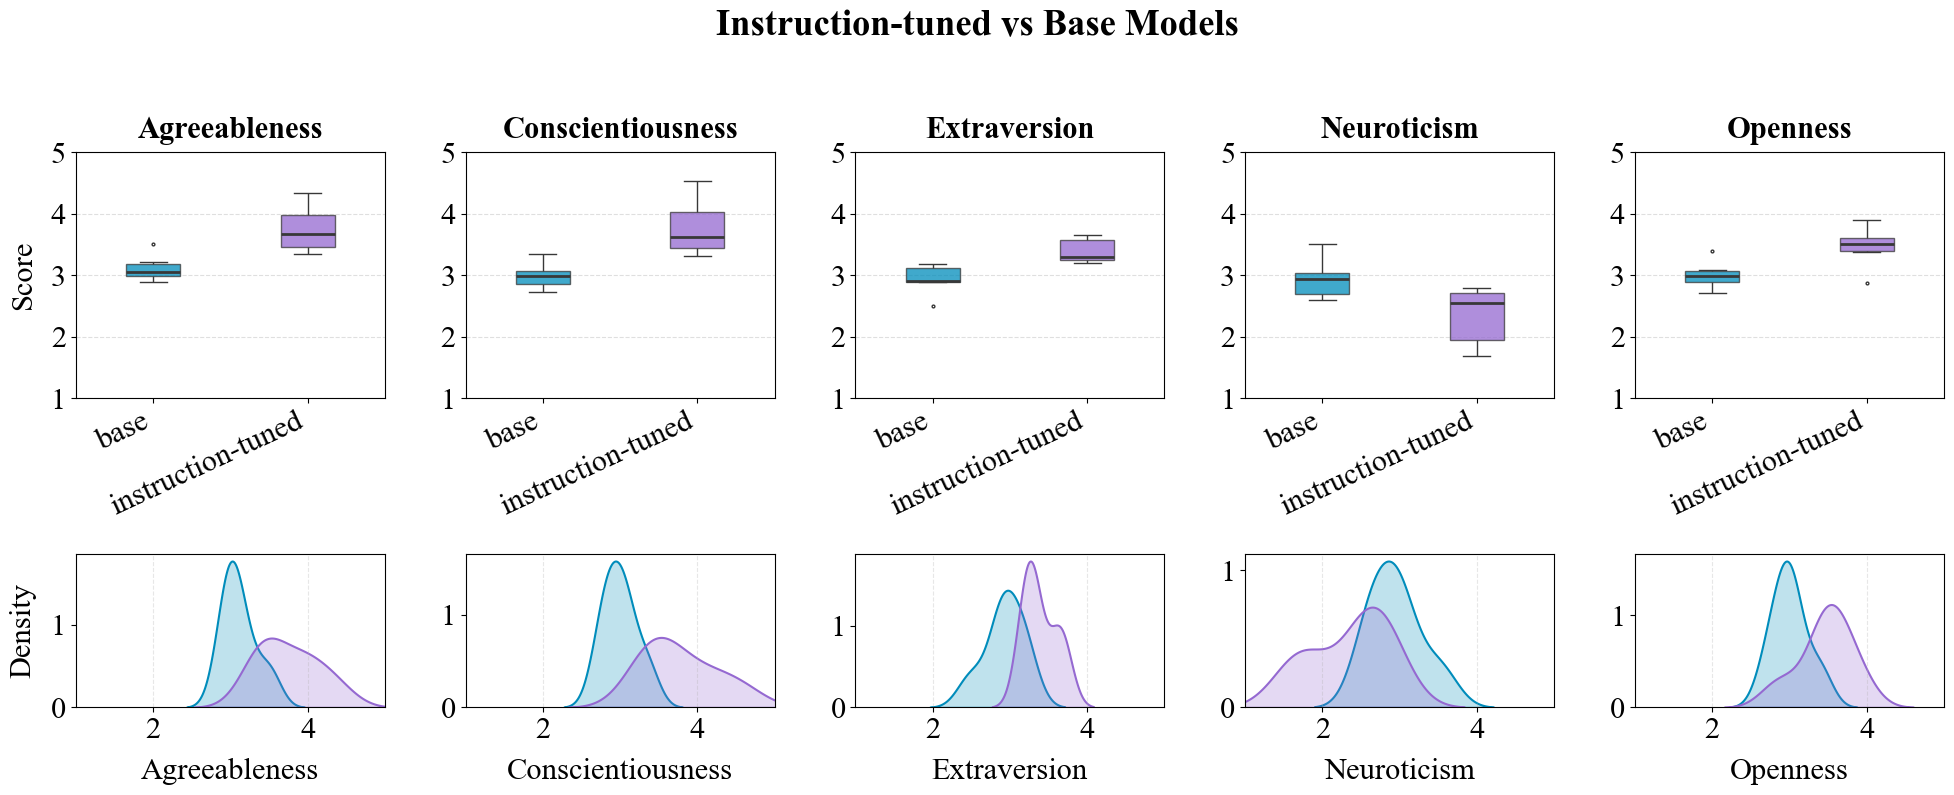

In [6]:
### 5) FIGURE — instruction-tuned vs base
# Reuse bonferroni_ttest for annotation (independent groups here)
stats_annot = bonferroni_ttest(df_it_base, "group", cols=OCEAN_COLS)

fig = plot_binary_comparison(
    df_it_base,
    group_col="group",
    title="Instruction-tuned vs Base Models",
    palette=BINARY_PAL_BLUE_PURPLE,
    order=["base", "instruction-tuned"],
    stats_df=stats_annot,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_it_vs_base.pdf",
    t_test = False
)
plt.show()

## 3.2 Open-weight vs Proprietary

In [7]:
### 6) OPEN-WEIGHT vs PROPRIETARY
df_lic    = df_metadata.dropna(subset=["license_group"] + OCEAN_COLS)
stats_lic = bonferroni_ttest(df_lic, "license_group", cols=OCEAN_COLS)

print_group_stats(df_lic, "license_group")
print()
print(stats_lic.to_string(index=False))


───────────────────────────────────────────────────────
Mean & SD by license_group
───────────────────────────────────────────────────────

  [open-weight]  n=113
    Agreeableness            : mean=3.932  sd=0.540
    Conscientiousness        : mean=3.909  sd=0.583
    Extraversion             : mean=3.586  sd=0.493
    Neuroticism              : mean=2.166  sd=0.560
    Openness                 : mean=3.564  sd=0.625

  [proprietary]  n=109
    Agreeableness            : mean=4.259  sd=0.377
    Conscientiousness        : mean=4.359  sd=0.421
    Extraversion             : mean=3.807  sd=0.400
    Neuroticism              : mean=1.792  sd=0.408
    Openness                 : mean=3.984  sd=0.490

            trait      group1      group2      t  p_bonferroni sig
    Agreeableness open-weight proprietary -5.259        0.0000 ***
Conscientiousness open-weight proprietary -6.609        0.0000 ***
     Extraversion open-weight proprietary -3.676        0.0015  **
      Neuroticism open-

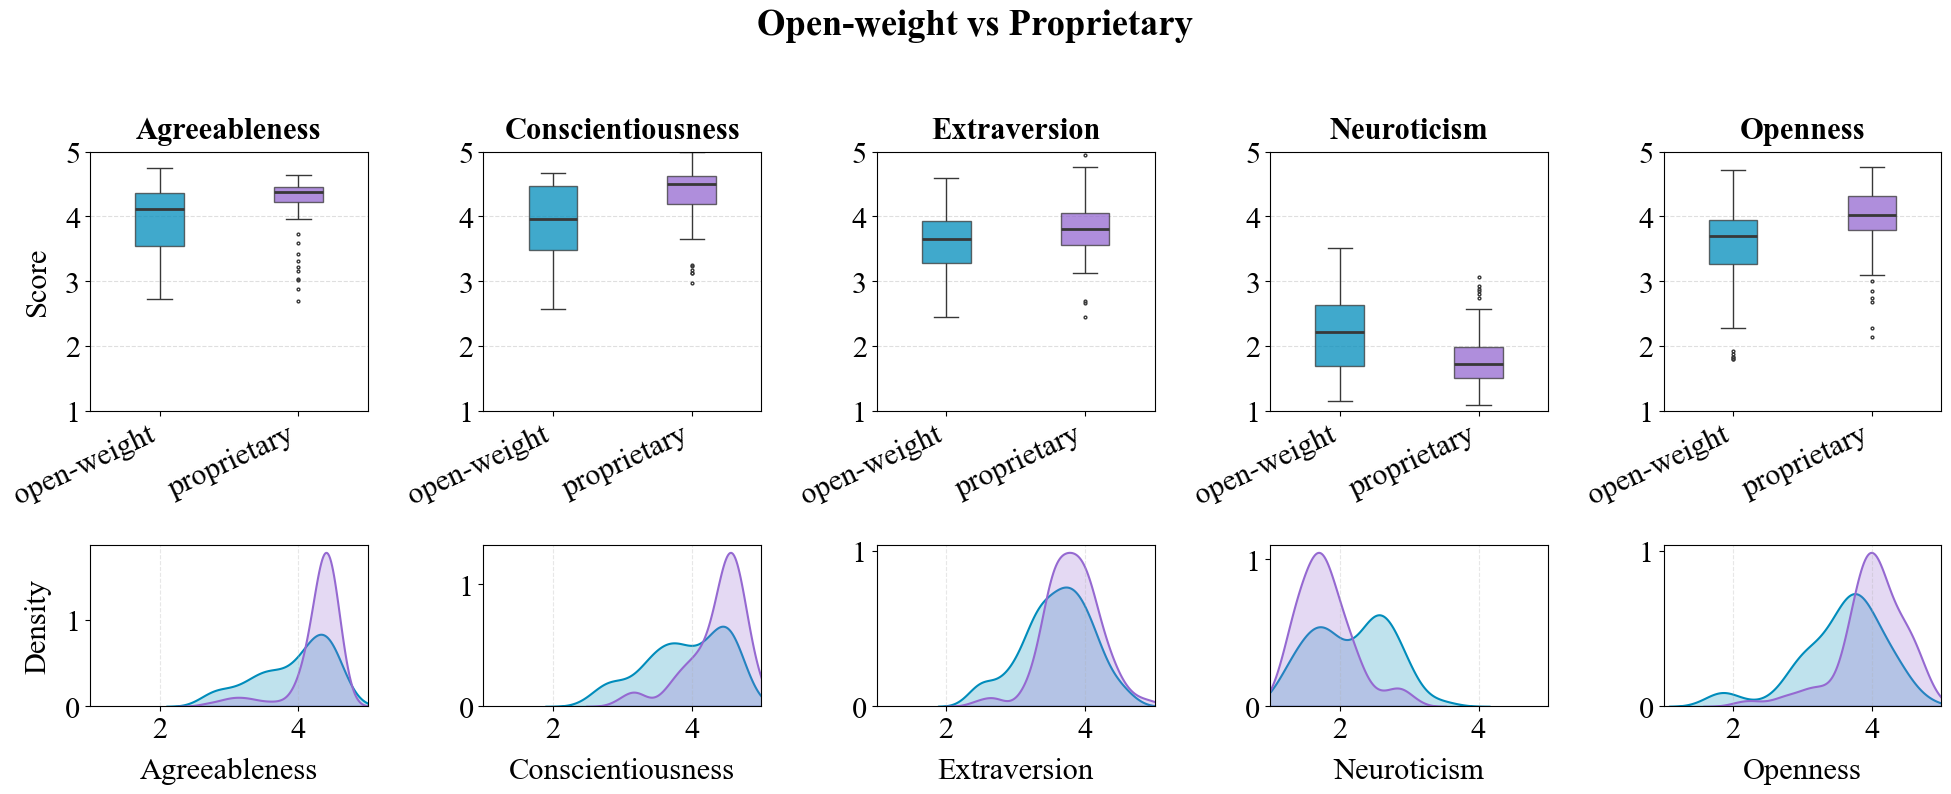

In [8]:
### 7) FIGURE — open-weight vs proprietary
fig = plot_binary_comparison(
    df_lic,
    group_col="license_group",
    title="Open-weight vs Proprietary",
    palette=BINARY_PAL_BLUE_PURPLE,
    order=["open-weight", "proprietary"],
    stats_df=stats_lic,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_proprietary_openweight.pdf",
    t_test = False
)
plt.show()

## 3.3 Reasoning vs Non-Reasoning

In [9]:
### 8) REASONING TRUE vs FALSE
REASONING_COL = "Reasoning"

df_reas = df_metadata.dropna(subset=[REASONING_COL] + OCEAN_COLS).copy()
df_reas[REASONING_COL] = df_reas[REASONING_COL].astype(str).str.strip().str.upper()
df_reas = df_reas[df_reas[REASONING_COL].isin(["TRUE", "FALSE"])]

stats_reas = bonferroni_ttest(df_reas, REASONING_COL, cols=OCEAN_COLS)

print_group_stats(df_reas, REASONING_COL)
print()
print(stats_reas.to_string(index=False))


───────────────────────────────────────────────────────
Mean & SD by Reasoning
───────────────────────────────────────────────────────

  [FALSE]  n=130
    Agreeableness            : mean=3.990  sd=0.456
    Conscientiousness        : mean=3.998  sd=0.519
    Extraversion             : mean=3.684  sd=0.429
    Neuroticism              : mean=2.182  sd=0.518
    Openness                 : mean=3.699  sd=0.444

  [TRUE]  n=92
    Agreeableness            : mean=4.238  sd=0.512
    Conscientiousness        : mean=4.315  sd=0.558
    Extraversion             : mean=3.709  sd=0.507
    Neuroticism              : mean=1.700  sd=0.388
    Openness                 : mean=3.870  sd=0.760

            trait group1 group2      t  p_bonferroni sig
    Agreeableness  FALSE   TRUE -3.726        0.0013  **
Conscientiousness  FALSE   TRUE -4.290        0.0001 ***
     Extraversion  FALSE   TRUE -0.379        1.0000  ns
      Neuroticism  FALSE   TRUE  7.923        0.0000 ***
         Openness  FALSE

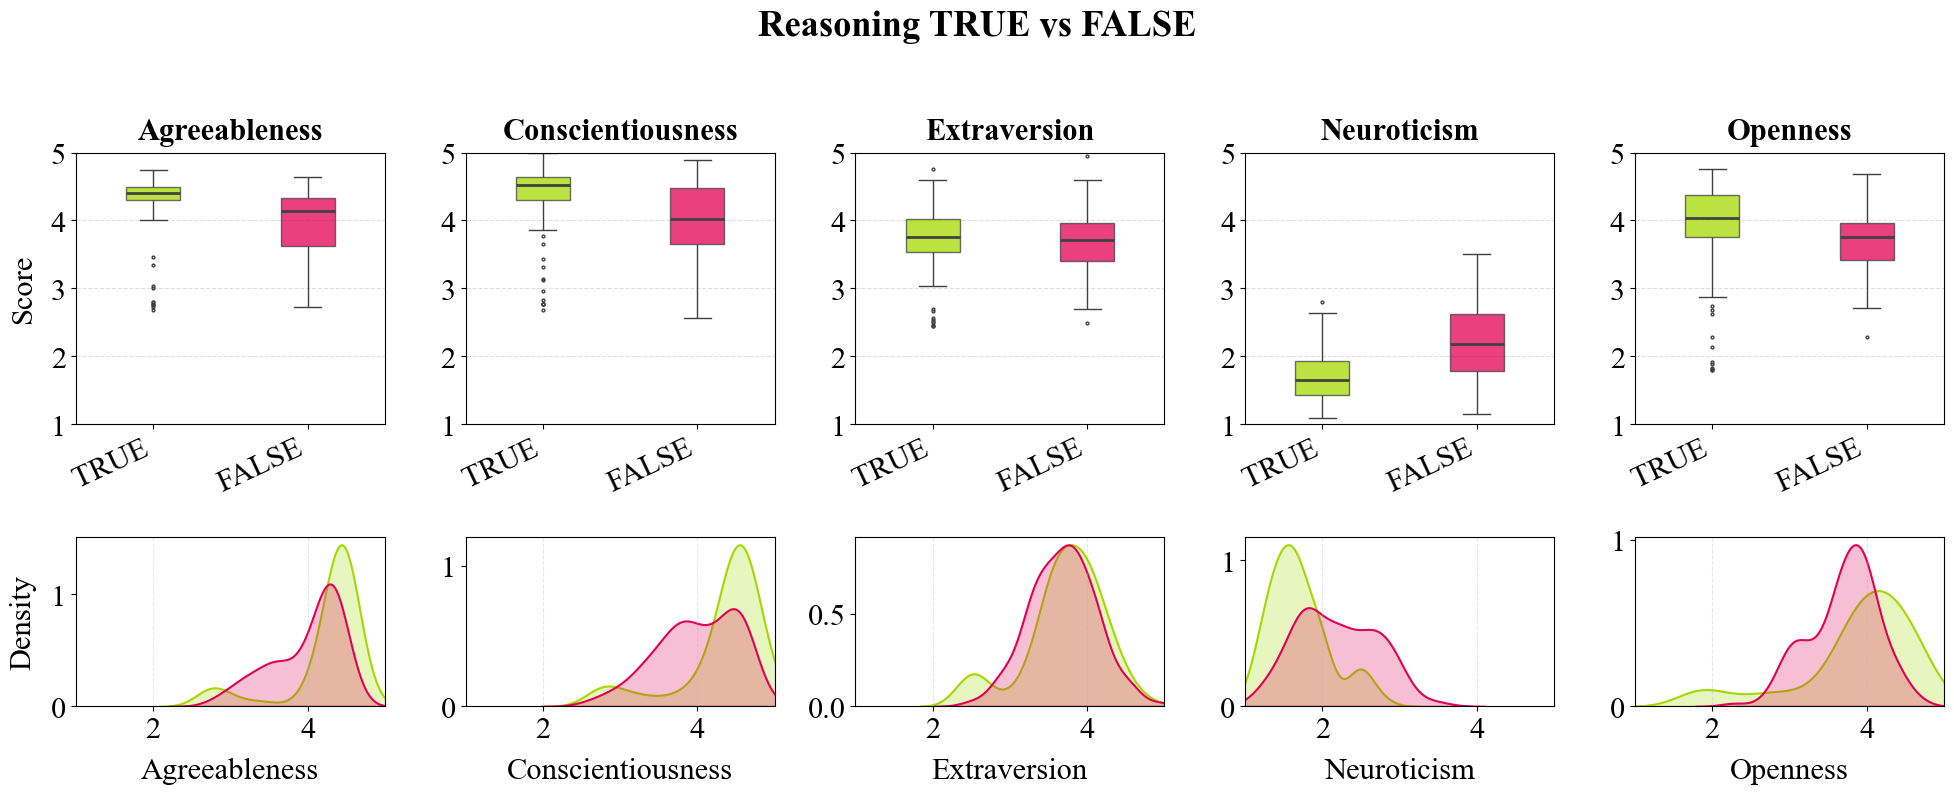

In [10]:
### 9) FIGURE — reasoning vs non-reasoning
fig = plot_binary_comparison(
    df_reas,
    group_col=REASONING_COL,
    title="Reasoning TRUE vs FALSE",
    palette=BINARY_PAL_GREEN_RED,
    order=["TRUE", "FALSE"],
    stats_df=stats_reas,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_reasoning.pdf",
    t_test=False
)
plt.show()

## 3.4 Geographic Origin

In [11]:
### 10) COUNTRY OF ORIGIN
df_metadata["Country"] = df_metadata["Country"].replace({
    "china": "China", "france": "France", "US": "US",
})

country_counts = df_metadata["Country"].value_counts()
valid_countries = country_counts[country_counts > 5].index

df_ctry = (
    df_metadata[df_metadata["Country"].isin(valid_countries)]
    .dropna(subset=["Country"] + OCEAN_COLS)
)
ctry_order = (
    df_ctry.groupby("Country")["Openness"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

print_group_stats(df_ctry, "Country")


───────────────────────────────────────────────────────
Mean & SD by Country
───────────────────────────────────────────────────────

  [China]  n=97
    Agreeableness            : mean=4.108  sd=0.559
    Conscientiousness        : mean=4.114  sd=0.607
    Extraversion             : mean=3.670  sd=0.505
    Neuroticism              : mean=1.880  sd=0.538
    Openness                 : mean=3.705  sd=0.696

  [France]  n=20
    Agreeableness            : mean=3.888  sd=0.330
    Conscientiousness        : mean=3.821  sd=0.399
    Extraversion             : mean=3.694  sd=0.366
    Neuroticism              : mean=2.510  sd=0.400
    Openness                 : mean=3.753  sd=0.428

  [US]  n=96
    Agreeableness            : mean=4.131  sd=0.448
    Conscientiousness        : mean=4.233  sd=0.516
    Extraversion             : mean=3.721  sd=0.445
    Neuroticism              : mean=1.950  sd=0.470
    Openness                 : mean=3.848  sd=0.537


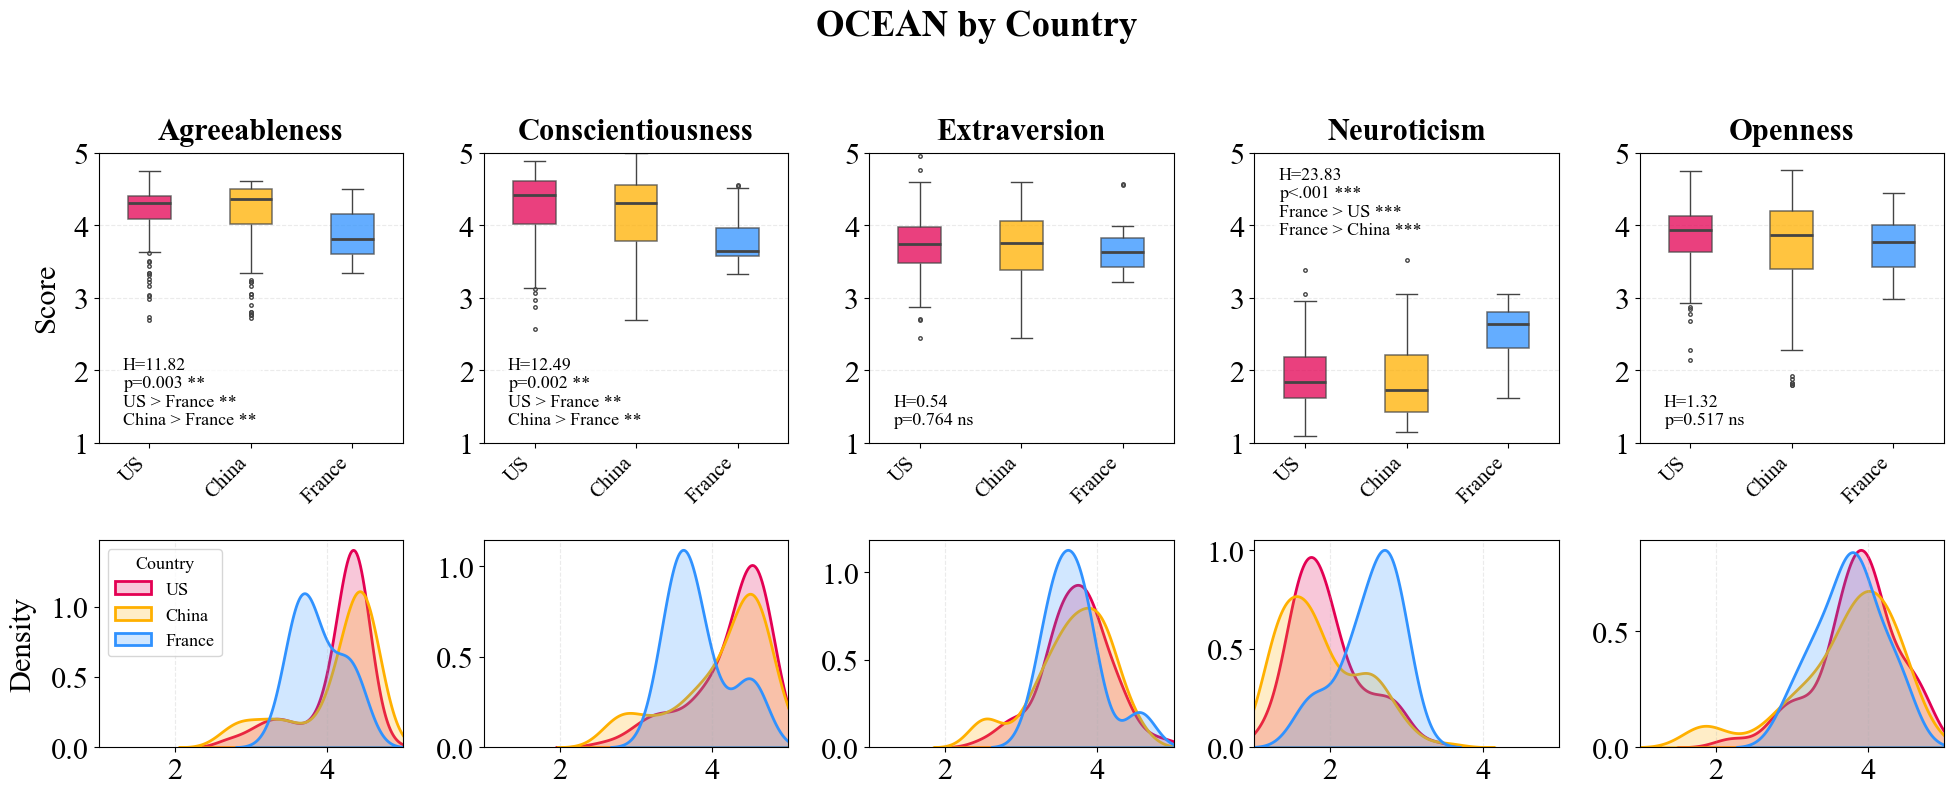

In [12]:
### 11) FIGURE — geographic origin
fig = plot_multigroup_comparison(
    df_ctry,
    group_col="Country",
    title="OCEAN by Country",
    palette=sns.color_palette(TRI_COLOR, df_ctry["Country"].nunique()),
    order=ctry_order,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_countries.pdf",
)
plt.show()

## 3.5 Model Family Profiles

In [13]:
### 12) MODEL FAMILY — group small families into 'other'
MIN_MODELS = 7

df_fam_base  = df_metadata.dropna(subset=["Family"] + OCEAN_COLS)
family_counts = df_fam_base["Family"].value_counts()
keep_families = family_counts[family_counts >= MIN_MODELS].index.tolist()

df_family = df_fam_base.copy()
df_family["FamilyGrouped"] = np.where(
    df_family["Family"].isin(keep_families),
    df_family["Family"],
    "other",
)

family_order = (
    df_family[df_family["FamilyGrouped"] != "other"]
    .groupby("FamilyGrouped")["Openness"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
) + ["other"]

print(df_family["FamilyGrouped"].value_counts())
print_group_stats(df_family, "FamilyGrouped")

FamilyGrouped
other       65
qwen        46
gpt         21
mistral     20
glm         12
deepseek    10
grok        10
claude       9
gemma        8
seed         7
gemini       7
llama        7
Name: count, dtype: int64

───────────────────────────────────────────────────────
Mean & SD by FamilyGrouped
───────────────────────────────────────────────────────

  [claude]  n=9
    Agreeableness            : mean=4.268  sd=0.238
    Conscientiousness        : mean=4.305  sd=0.277
    Extraversion             : mean=3.533  sd=0.180
    Neuroticism              : mean=1.919  sd=0.180
    Openness                 : mean=4.016  sd=0.084

  [deepseek]  n=10
    Agreeableness            : mean=3.821  sd=0.735
    Conscientiousness        : mean=3.703  sd=0.714
    Extraversion             : mean=3.601  sd=0.773
    Neuroticism              : mean=2.179  sd=0.292
    Openness                 : mean=3.304  sd=1.021

  [gemini]  n=7
    Agreeableness            : mean=4.011  sd=0.800
    Conscienti

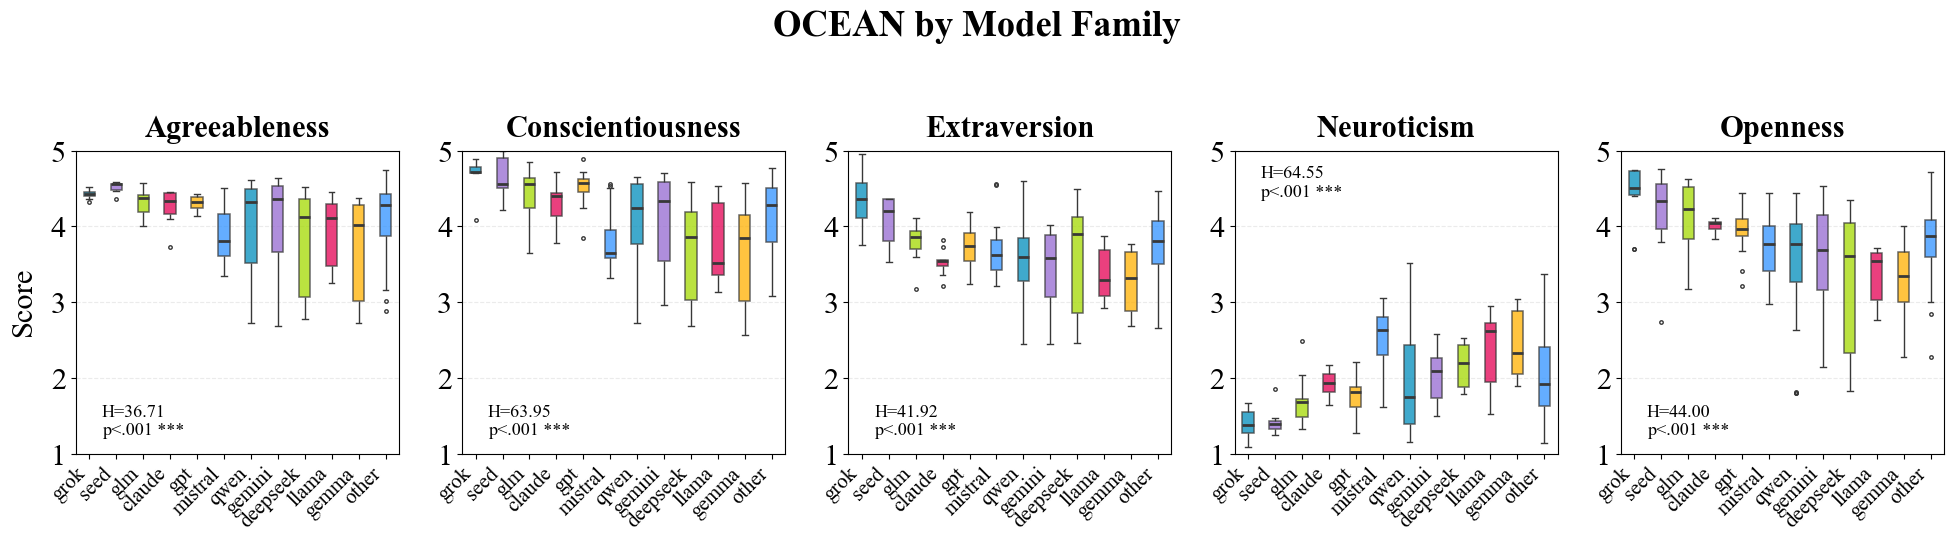

In [14]:
### 13) FIGURE — model family boxplot
n_families = df_family["FamilyGrouped"].nunique()

fig = plot_multigroup_comparison(
    df_family,
    group_col="FamilyGrouped",
    title="OCEAN by Model Family",
    palette=sns.color_palette(IMPACT_SIX, n_families),
    order=family_order,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_families.pdf",
    figsize=(4 * len(OCEAN_COLS), 5.5),
    test = True,
    posthoc = False,
    kde = False
)
plt.show()

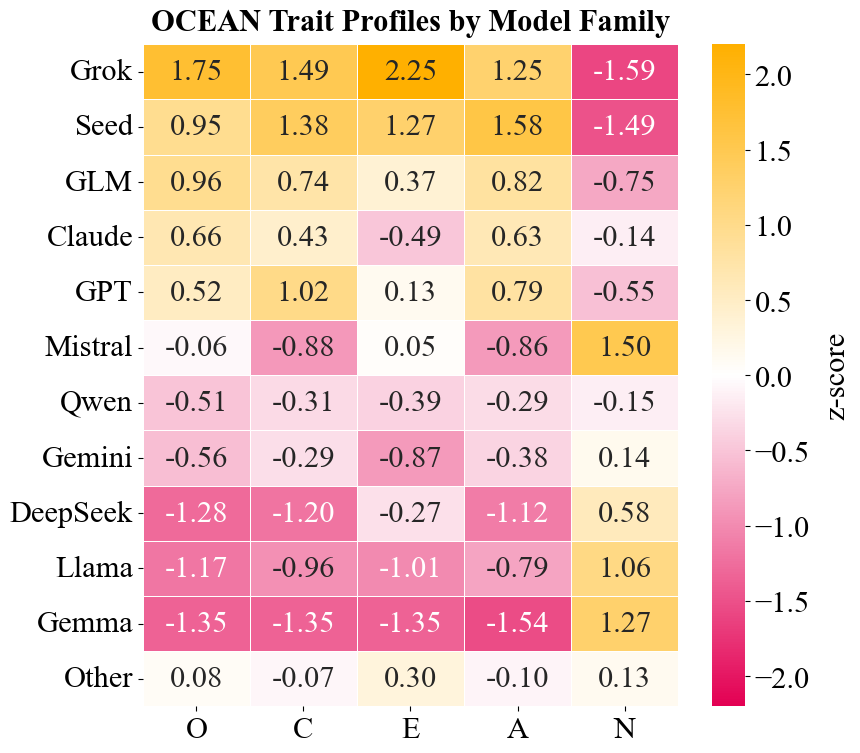

In [15]:
### 14) FIGURE — model family z-score heatmap
fig = plot_family_heatmap(
    df_family,
    group_col="FamilyGrouped",
    order=family_order,
    cols=OCEAN_COLS,
    title="OCEAN Trait Profiles by Model Family",
    save_path="../../doc/figs/fig_heatmap_families.pdf",
)
plt.show()

## 3.6 Parameter Scale

In [16]:
### 15) SIZE GROUP COMPARISON (Kruskal-Wallis)
SIZE_ORDER = ["small (<10B)", "medium (10–100B)", "large (>100B)"]

df_sz      = df_metadata.dropna(subset=["Size"] + OCEAN_COLS)
sz_present = [s for s in SIZE_ORDER if s in df_sz["Size"].values]

print_group_stats(df_sz, "Size")


───────────────────────────────────────────────────────
Mean & SD by Size
───────────────────────────────────────────────────────

  [large]  n=38
    Agreeableness            : mean=4.197  sd=0.437
    Conscientiousness        : mean=4.190  sd=0.472
    Extraversion             : mean=3.805  sd=0.469
    Neuroticism              : mean=1.866  sd=0.444
    Openness                 : mean=3.787  sd=0.577

  [medium]  n=46
    Agreeableness            : mean=3.942  sd=0.523
    Conscientiousness        : mean=3.914  sd=0.575
    Extraversion             : mean=3.590  sd=0.483
    Neuroticism              : mean=2.200  sd=0.544
    Openness                 : mean=3.547  sd=0.684

  [small]  n=34
    Agreeableness            : mean=3.647  sd=0.503
    Conscientiousness        : mean=3.620  sd=0.548
    Extraversion             : mean=3.379  sd=0.438
    Neuroticism              : mean=2.477  sd=0.505
    Openness                 : mean=3.393  sd=0.508

  [undisclosed]  n=104
    Agreeable

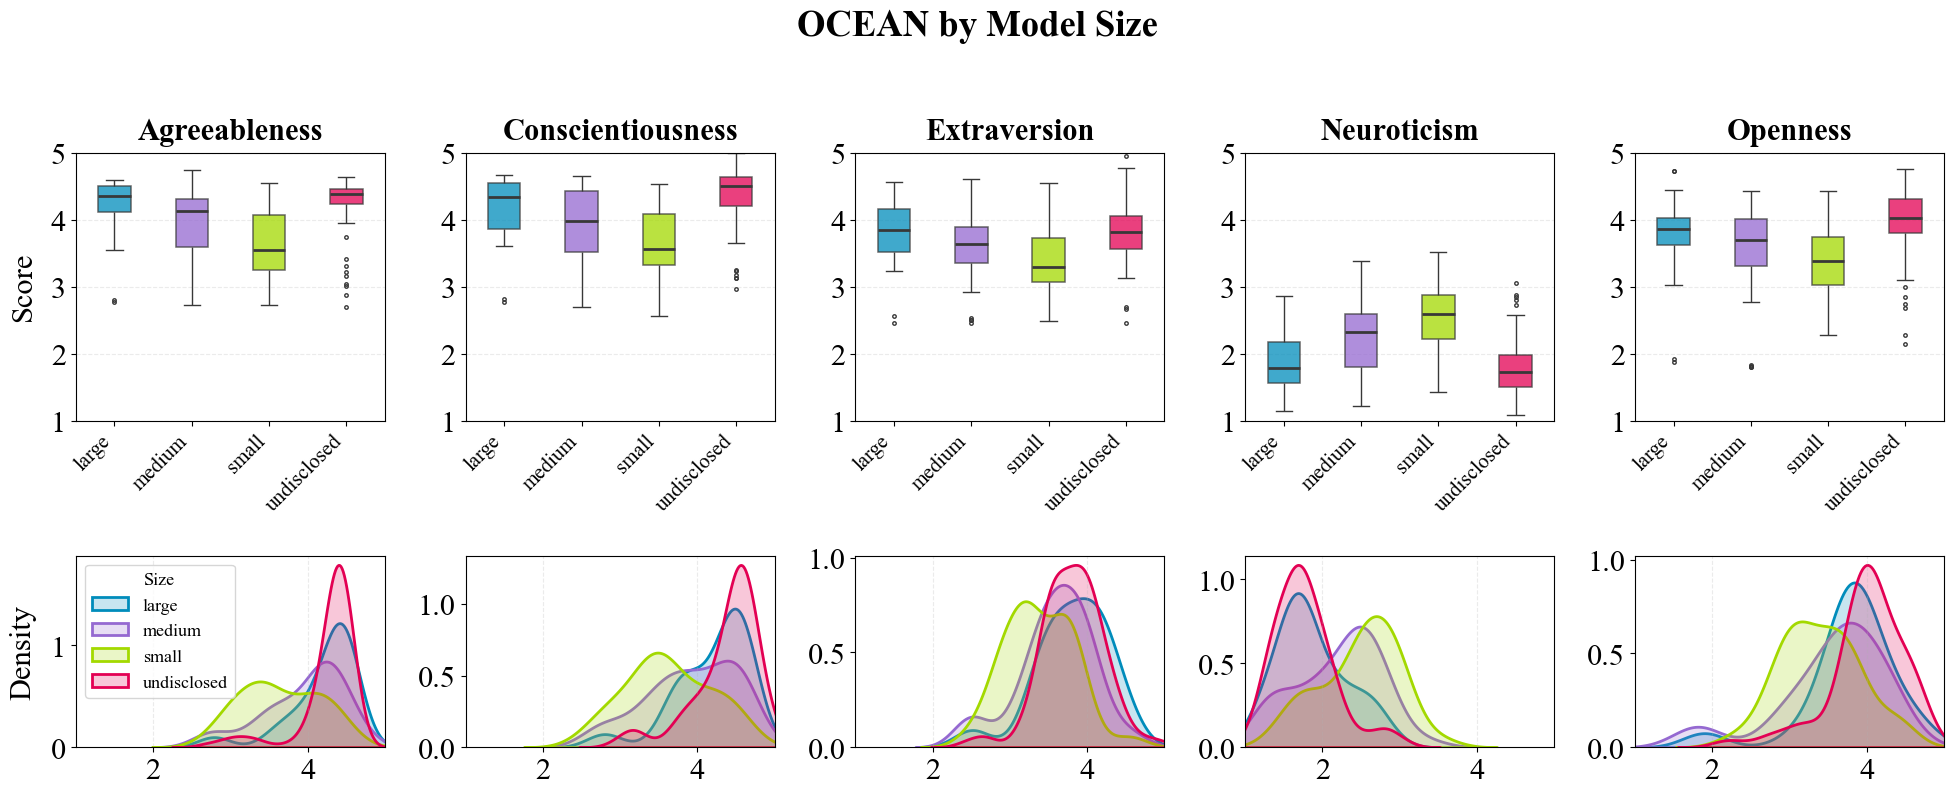

In [17]:
### 16) FIGURE — model size groups
fig = plot_multigroup_comparison(
    df_sz,
    group_col="Size",
    title="OCEAN by Model Size",
    palette=IMPACT_SIX,
    order=sz_present,
    cols=OCEAN_COLS,
    save_path="../../doc/figs/fig_sizes.pdf",
    test=False,
    posthoc = False,
)
plt.show()

In [18]:
df_metadata.columns

Index(['model', 'Agreeableness', 'Conscientiousness', 'Extraversion',
       'Neuroticism', 'Openness', 'social-desirability', 'Model_name',
       'Reasoning', 'Provider', 'Company', 'Family', 'Region', 'Country',
       'Parameters_B', 'Size', 'License', 'Release_date', 'MT_Bench',
       'Alignment', 'license_group', 'params_numeric'],
      dtype='str')

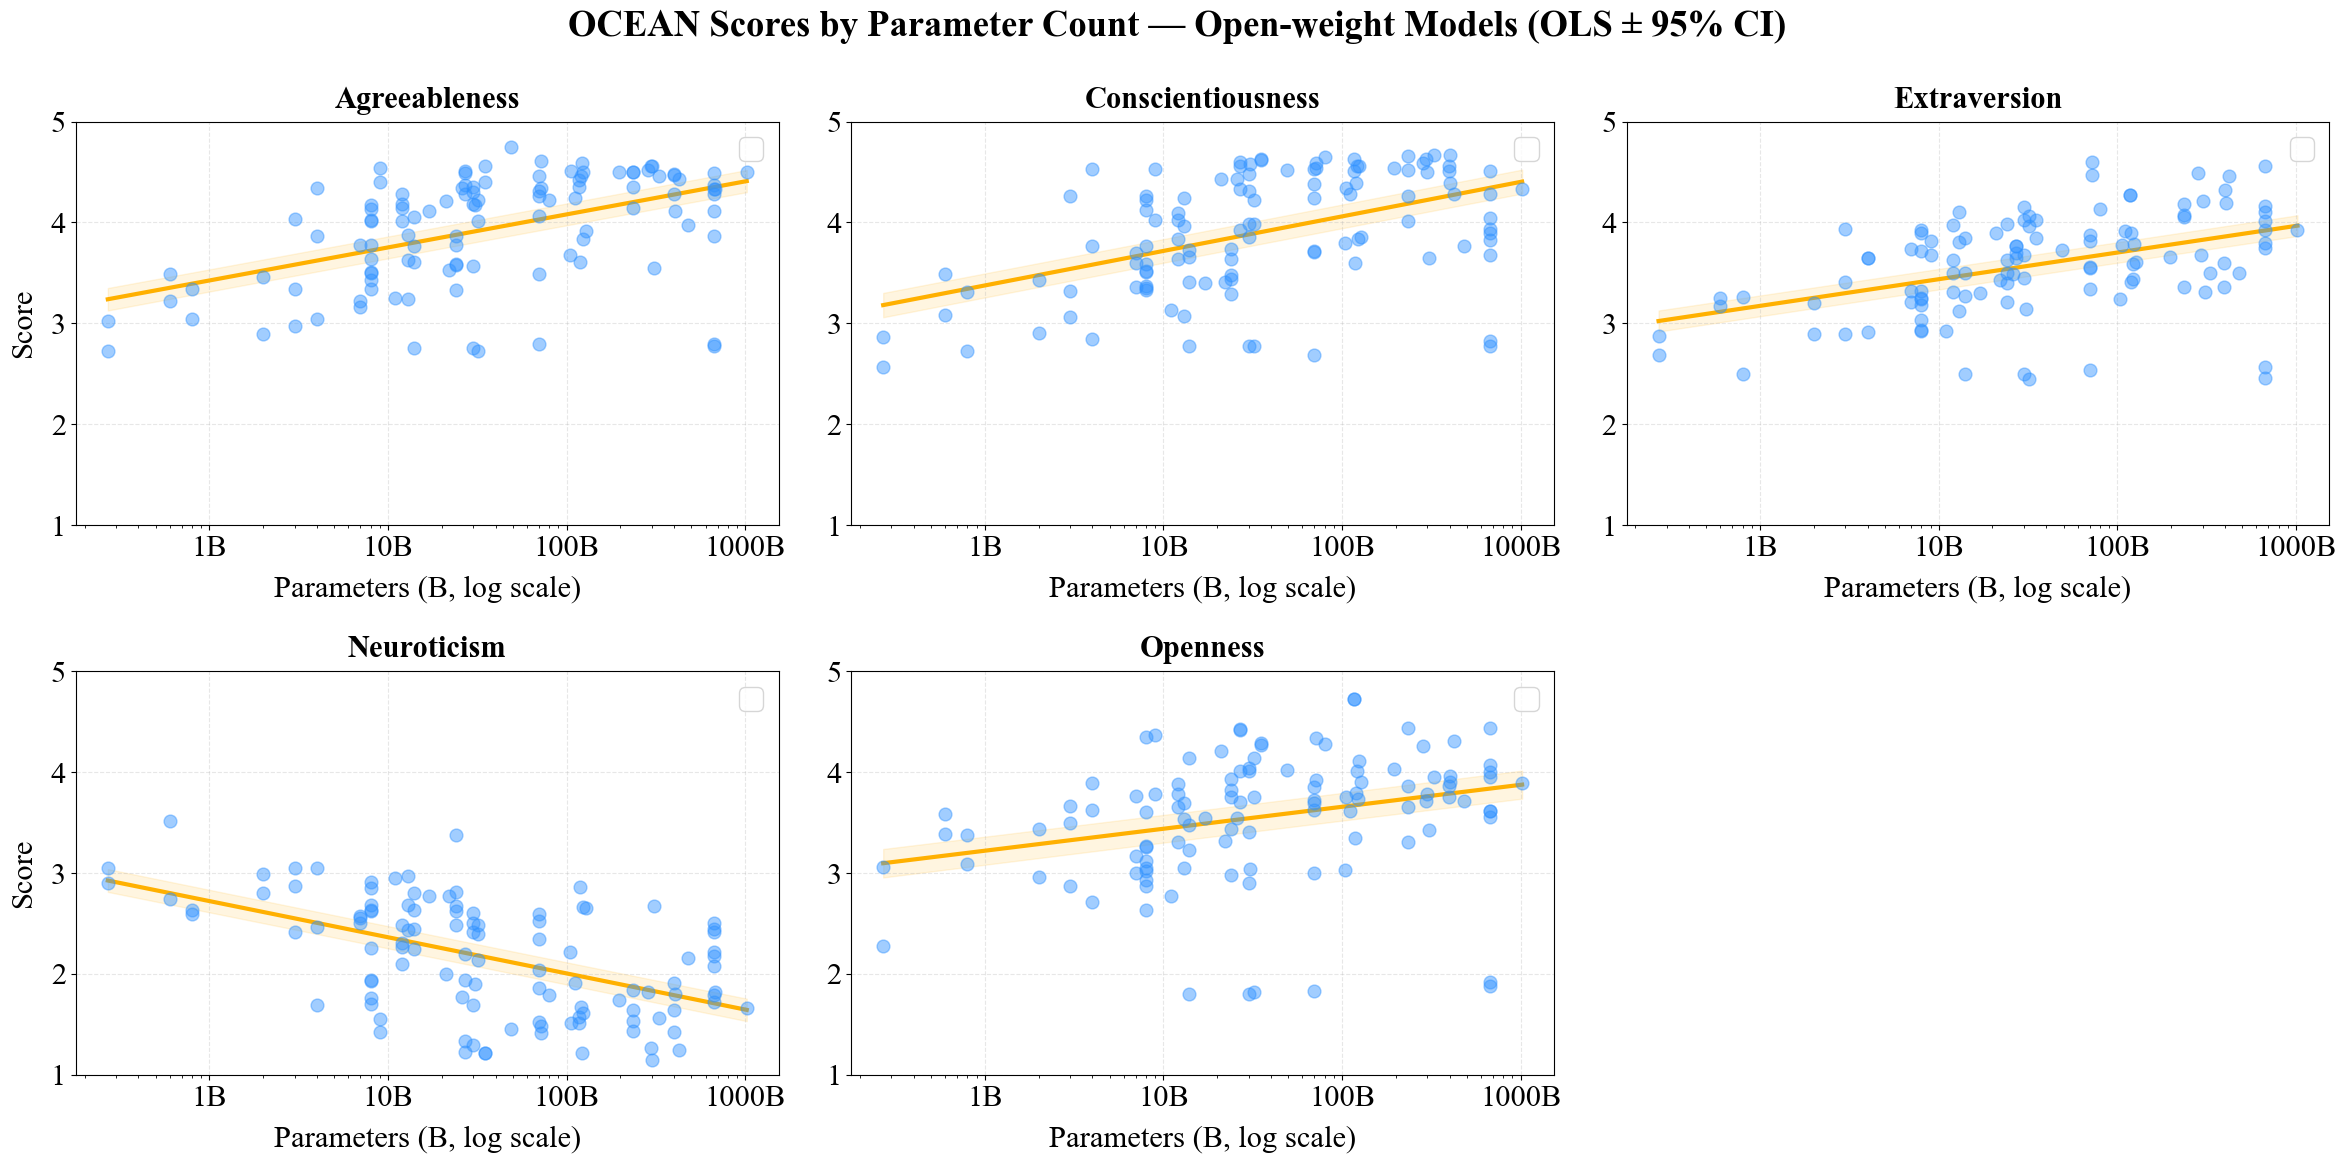

In [19]:
### 17) CONTINUOUS PARAMETER SCALE (OLS regression on log10 params)
fig = plot_param_scale_regression(
    df_metadata,
    params_col="Parameters_B",
    palette=BINARY_PAL_BLUE_ORANGE,
    cols=OCEAN_COLS,
    title="OCEAN Scores by Parameter Count — Open-weight Models (OLS ± 95% CI)",
    save_path="../../doc/figs/fig_size_regression.pdf",
    test = False
)
plt.show()

## 3.7 Release Date Trends

In [20]:
### 18) RELEASE DATE — preprocessing
import pandas as pd

ref = pd.Timestamp("2026-05-12")

df_metadata["release_dt"]     = pd.to_datetime(df_metadata["Release_date"], errors="coerce")
df_metadata["release_months"] = (df_metadata["release_dt"] - ref).dt.days / 30.44

In [21]:
### 19) REGRESSION SUMMARY — release date vs OCEAN
df_rel     = df_metadata.dropna(subset=["release_months"] + OCEAN_COLS)
summary_df = regression_summary(df_rel, x_col="release_months", y_cols=OCEAN_COLS)

print("=== OLS: OCEAN ~ release_months ===")
print(summary_df.to_string(index=False))

=== OLS: OCEAN ~ release_months ===
            trait    slope      r  p_value sig
      Neuroticism -0.02421 -0.309  0.00000 ***
Conscientiousness  0.02222  0.268  0.00005 ***
         Openness  0.02230  0.249  0.00018 ***
    Agreeableness  0.01691  0.229  0.00057 ***
     Extraversion  0.00452  0.066  0.33028  ns


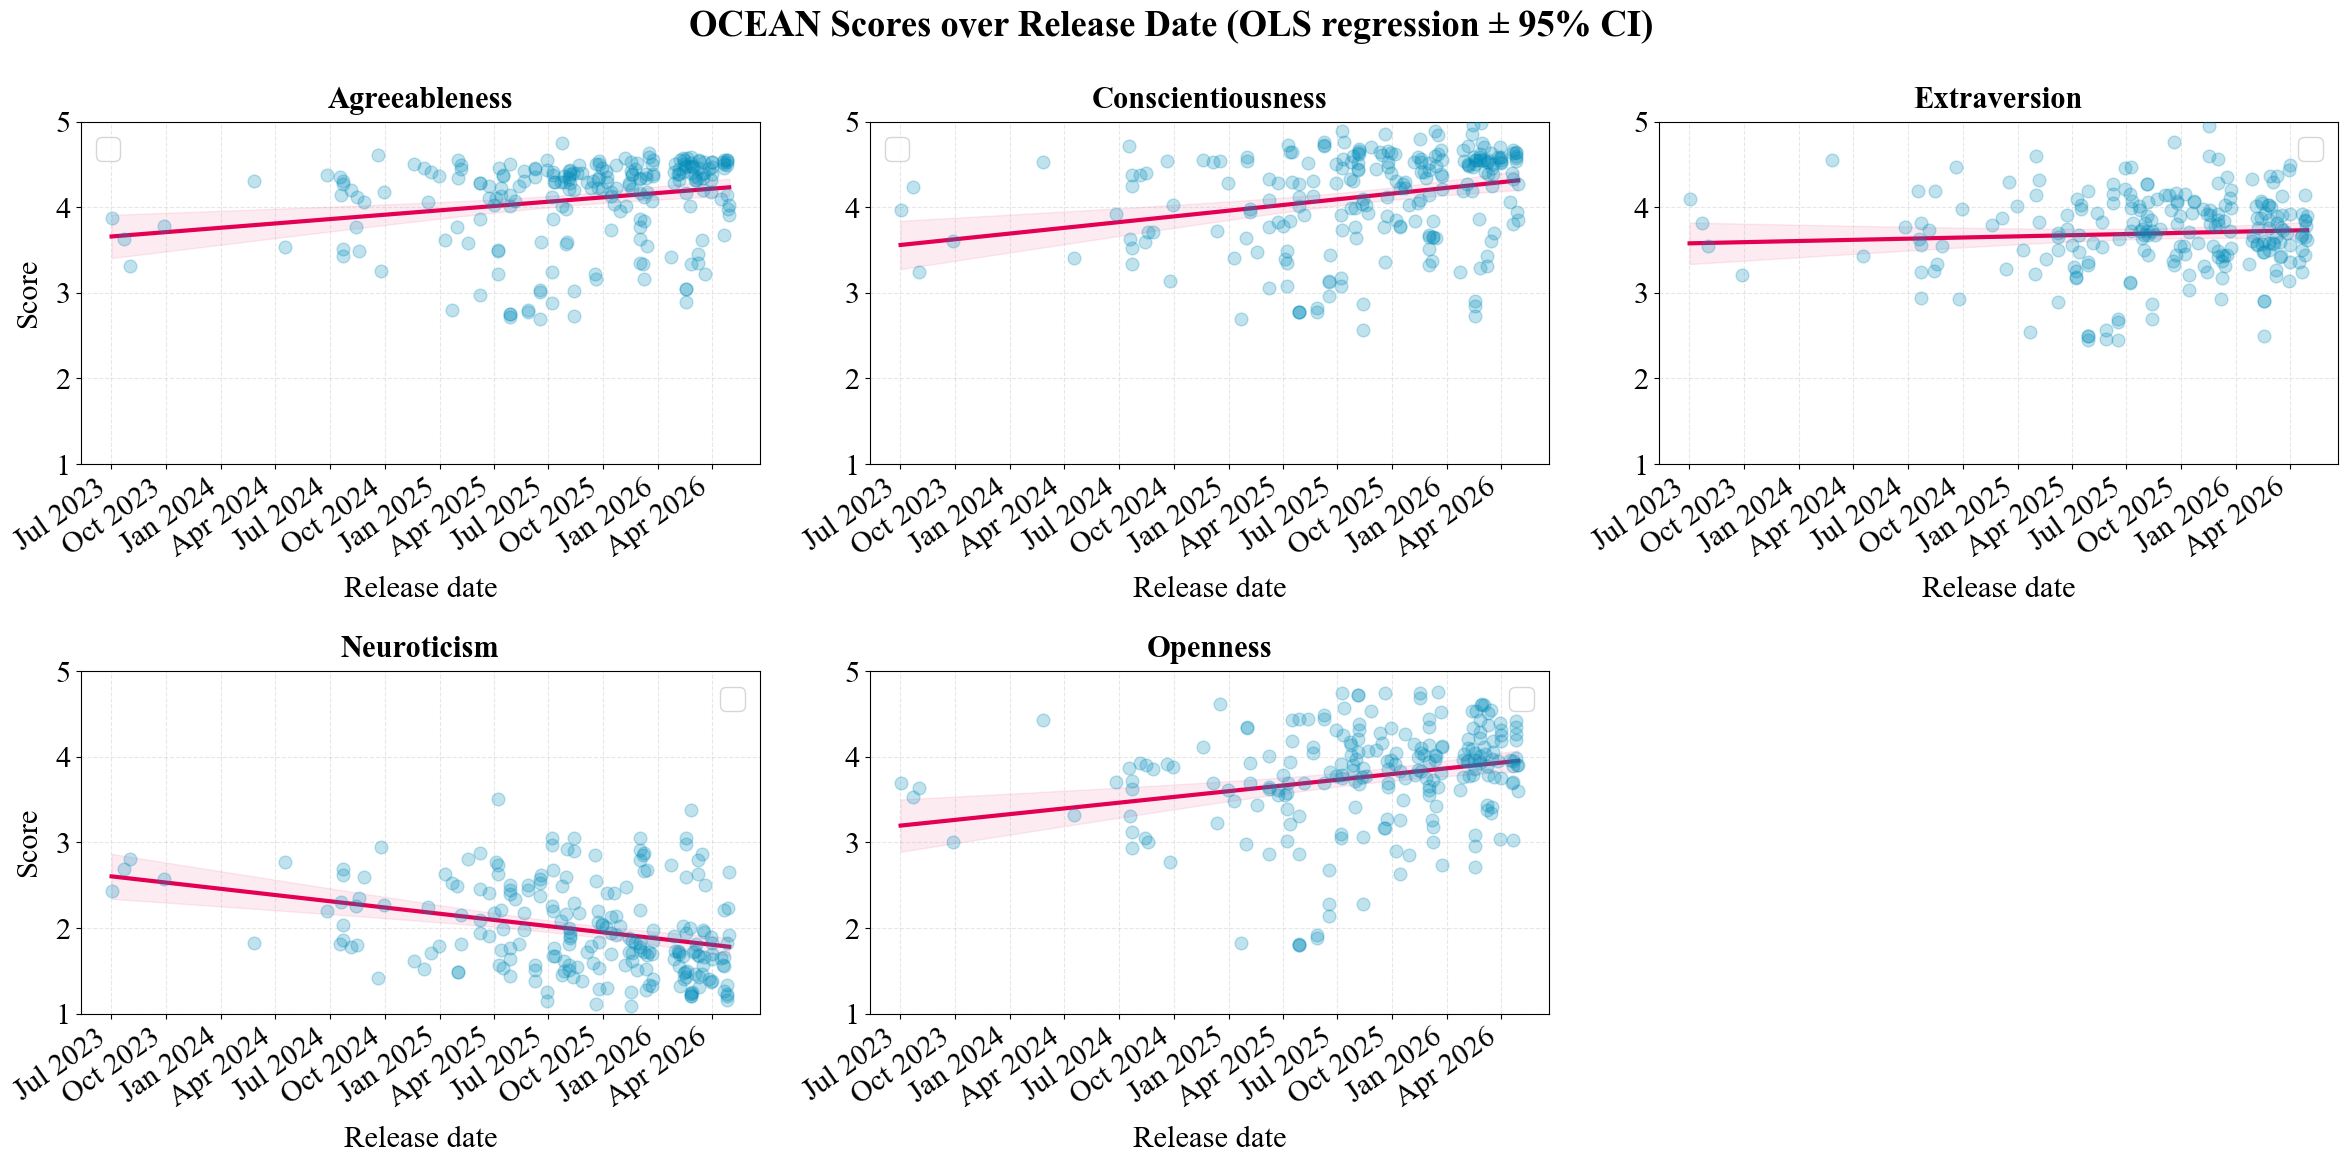

In [22]:
### 20) FIGURE — release date regression
df_rel = df_metadata.dropna(subset=["release_dt", "release_months"] + OCEAN_COLS)

fig = plot_release_date_regression(
    df_rel,
    date_col="release_dt",
    release_months_col="release_months",
    palette=BINARY_PAL_BLUE_PINK,
    cols=OCEAN_COLS,
    title="OCEAN Scores over Release Date (OLS regression ± 95% CI)",
    save_path="../../doc/figs/fig_release_date.pdf",
    test=False
)
plt.show()